# Thalyann Olivo
June 8th, 2026

## Analytical Approach
- To examine 21 million NYC 311 service requests between 2020 and 2026, my approach was to use perform an EDA calculating complaint volume, identifying seasonal patterns in complaint types, and at the same time correcting data quality issues affecting resolution times, before drawing any conculsions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# Exploratory Data Analysis (EDA) and Visualization

In [ ]:
# Extracting and Combining Parquet Files

EXCLUDE = {"311_UNKNOWN.parquet", "311_UNSPECIFIED.parquet"}

CSV_DIR = "nyc311_by_borough"
parquet_files = [
    f for f in glob.glob(os.path.join(CSV_DIR, "311_*.parquet"))
    if os.path.basename(f) not in EXCLUDE
]
df_list = [pd.read_parquet(file) for file in parquet_files]
df = pd.concat(df_list, ignore_index=True)

In [ ]:
# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("Dataset Columns:", df.columns)

Dataset Shape: (21251334, 28)
Dataset Columns: Index(['unique_key', 'created_date', 'closed_date', 'agency', 'agency_name',
       'complaint_type', 'descriptor', 'descriptor_2', 'incident_zip',
       'intersection_street_1', 'intersection_street_2', 'address_type',
       'city', 'status', 'resolution_description',
       'resolution_action_updated_date', 'community_board', 'council_district',
       'police_precinct', 'borough', 'x_coordinate_state_plane',
       'y_coordinate_state_plane', 'open_data_channel_type',
       'park_facility_name', 'park_borough', 'latitude', 'longitude',
       'location'],
      dtype='str')


In [ ]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 21251334 entries, 0 to 21251333
Data columns (total 28 columns):
 #   Column                          Dtype  
---  ------                          -----  
 0   unique_key                      int64  
 1   created_date                    str    
 2   closed_date                     str    
 3   agency                          str    
 4   agency_name                     str    
 5   complaint_type                  str    
 6   descriptor                      str    
 7   descriptor_2                    str    
 8   incident_zip                    float64
 9   intersection_street_1           str    
 10  intersection_street_2           str    
 11  address_type                    str    
 12  city                            str    
 13  status                          str    
 14  resolution_description          str    
 15  resolution_action_updated_date  str    
 16  community_board                 str    
 17  council_district      

In [ ]:
print("Dataset Description:")
df.describe()

Dataset Description:


,unique_key,incident_zip,x_coordinate_state_plane,y_coordinate_state_plane,latitude,longitude
count,2.125133e+07,2.102140e+07,2.092672e+07,2.092745e+07,2.092664e+07,2.092664e+07
mean,5.769999e+07,1.081435e+04,1.005902e+06,2.078786e+05,4.073720e+01,-7.392183e+01
std,6.826571e+06,5.374753e+02,2.258160e+04,3.188481e+04,8.795633e-02,7.956220e-02
min,4.028773e+07,0.000000e+00,9.133530e+05,-2.280004e+06,2.040075e-06,-7.425495e+01
25%,5.209067e+07,1.045100e+04,9.938770e+05,1.844690e+05,4.067294e+01,-7.396527e+01
50%,5.789048e+07,1.120100e+04,1.005189e+06,2.050830e+05,4.072953e+01,-7.392441e+01
75%,6.357998e+07,1.123400e+04,1.019345e+06,2.374000e+05,4.081823e+01,-7.387332e+01
max,6.924512e+07,1.234500e+04,3.113073e+07,2.720890e+05,4.091346e+01,-1.149235e-07


# EDA Questions

1. What are the top 10 most common complaint types (complaint_type) across the full dataset?
2. Which borough generates the most service requests? Does the distribution surprise you? Optional if you analyze multiple datasets.
3. What is the average resolution time (in days) by agency? Use created_date and closed_date to calculate. Which agency resolves requests fastest — and which is slowest?
4. Are there any complaint types that appear to be seasonal or concentrated in certain time periods? Use created_date to group by month. Show your evidence.
5. Identify at least one data quality issue in the dataset (hint: check incident_zip, closed_date, and status). How did you handle it?


In [ ]:
# 1. What are the top 10 most common complaint types across the full dataset?
top_complaints = df["complaint_type"].value_counts().head(10)
print("Top 10 Most Common Complaint Types:")
print(top_complaints)

Top 10 Most Common Complaint Types:
complaint_type
Illegal Parking                        2735105
Noise - Residential                    2442753
HEAT/HOT WATER                         1637340
Noise - Street/Sidewalk                1079715
Blocked Driveway                       1018616
UNSANITARY CONDITION                    658100
Request Large Bulky Item Collection     632142
Street Condition                        473175
Water System                            397961
Noise - Vehicle                         393761
Name: count, dtype: int64


In [ ]:
# 2. Which borough generates the most service requests?
borough_counts = df["borough"].value_counts()
print("Service Requests by Borough:")
print(borough_counts)

Service Requests by Borough:
borough
BROOKLYN         6381501
QUEENS           5110647
BRONX            4554476
MANHATTAN        4305994
STATEN ISLAND     898716
Name: count, dtype: int64


- This distribution is surprising considering Queens is the largest borough, but Brooklyn generates the most service requests.

In [5]:
# 3. What is the average resolution time (in days) by agency? 
# Use created_date and closed_date to calculate. 
# Which agency resolves requests fastest — and which is slowest?

df["resolution_time"] = (pd.to_datetime(df["closed_date"]) - pd.to_datetime(df["created_date"])).dt.days
agency_resolution_time = df.groupby("agency")["resolution_time"].mean().sort_values(na_position="first")
print("Average Resolution Time by Agency (in days):")
print(agency_resolution_time)

Average Resolution Time by Agency (in days):
agency
3-1-1                NaN
NYPD            0.072215
DHS             1.087572
DEP             4.566351
NYC311-PRD      5.221024
OSE             7.398334
DSNY            9.088443
DCWP            9.509529
DFTA           12.004008
DOT            12.674862
HPD            15.848525
OTI            17.591691
DOITT          30.462500
DCA            32.709687
OOS            43.006044
TLC            45.671977
DOB            52.236813
DOE            88.401481
DOHMH         147.798695
DPR           184.143774
EDC           326.181469
Name: resolution_time, dtype: float64


In [ ]:
# Examining the single 3-1-1 complaint
single_complaint = df.loc[df["agency"] == "3-1-1"]
print("Single 3-1-1 Complaint:")
single_complaint

Single 3-1-1 Complaint:


,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,incident_zip,intersection_street_1,...,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,latitude,longitude,location,resolution_time
11971265,61332341,2024-06-01T03:00:53.000,NaN,3-1-1,3-1-1,Noise - Commercial,Loud Music/Party,NaN,11106.0,30 STREET,...,QUEENS,1004698.0,217030.0,UNKNOWN,Unspecified,QUEENS,40.76235,-73.926186,"{'type': 'Point', 'coordinates': [-73.92618622...",NaN


- The NYPD resolves requests the fastest, with an average 1.7 hours from created date to closed date.

- The EDC resolves requests the slowest, averaging 326 days from created date to closed date.

- The 3-1-1 NaN value appears to be an unrouted complaint; using context of the rest of the dataset, it can be properly assigned an agency

In [26]:
# Identifying the agency with the complaint_type "Noise - Commercial"
noise_commercial = df.loc[df["complaint_type"] == "Noise - Commercial"]
print("Noise - Commercial Complaints Sample:")
noise_commercial.sample(10)

Noise - Commercial Complaints Sample:


,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,incident_zip,intersection_street_1,...,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,latitude,longitude,location,resolution_time
9243126,50298865,2021-04-17T14:16:09.000,2021-04-17T14:52:04.000,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,NaN,11103.0,46 STREET,...,QUEENS,1008068.0,214954.0,MOBILE,Unspecified,QUEENS,40.756643,-73.914028,"{'type': 'Point', 'coordinates': [-73.91402846...",0.0
17777709,61087698,2024-05-07T14:22:20.000,2024-05-07T15:31:42.000,NYPD,New York City Police Department,Noise - Commercial,Car/Truck Horn,NaN,11217.0,BERGEN STREET,...,BROOKLYN,989870.0,187855.0,MOBILE,Unspecified,BROOKLYN,40.682294,-73.979737,"{'type': 'Point', 'coordinates': [-73.97973712...",0.0
750970,52783586,2021-12-14T00:03:34.000,2021-12-14T00:27:36.000,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,NaN,10009.0,EAST 1 STREET,...,MANHATTAN,987505.0,202865.0,PHONE,Unspecified,MANHATTAN,40.723494,-73.988257,"{'type': 'Point', 'coordinates': [-73.98825686...",0.0
8112379,50718957,2021-05-30T18:43:11.000,2021-05-30T18:43:52.000,NYPD,New York City Police Department,Noise - Commercial,Loud Talking,NaN,10472.0,GLEASON AVENUE,...,BRONX,1021327.0,241829.0,MOBILE,Unspecified,BRONX,40.830362,-73.866022,"{'type': 'Point', 'coordinates': [-73.86602154...",0.0
16421439,54534127,2022-06-19T01:11:59.000,2022-06-19T05:16:49.000,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,NaN,11207.0,COVERT STREET,...,BROOKLYN,1010312.0,191331.0,ONLINE,Unspecified,BROOKLYN,40.691798,-73.906020,"{'type': 'Point', 'coordinates': [-73.90602019...",0.0
11118742,60851491,2024-04-13T22:08:15.000,2024-04-13T22:32:23.000,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,NaN,11106.0,31 AVENUE,...,QUEENS,1005725.0,216709.0,ONLINE,Unspecified,QUEENS,40.761467,-73.922480,"{'type': 'Point', 'coordinates': [-73.92247996...",0.0
15855123,52282657,2021-10-23T22:08:48.000,2021-10-23T22:20:29.000,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,NaN,11211.0,BUSHWICK AVENUE,...,BROOKLYN,1000375.0,199678.0,ONLINE,Unspecified,BROOKLYN,40.714732,-73.941833,"{'type': 'Point', 'coordinates': [-73.94183310...",0.0
2716513,64945115,2025-05-14T10:03:39.000,2025-05-14T10:36:58.000,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,NaN,10029.0,2 AVENUE,...,MANHATTAN,1000984.0,227501.0,ONLINE,Unspecified,MANHATTAN,40.791098,-73.939567,"{'type': 'Point', 'coordinates': [-73.93956704...",0.0
19714532,46090855,2020-04-29T14:05:51.000,2020-04-29T14:07:07.000,NYPD,New York City Police Department,Noise - Commercial,Car/Truck Horn,NaN,11228.0,71 STREET,...,BROOKLYN,984030.0,165079.0,MOBILE,Unspecified,BROOKLYN,40.619780,-74.000792,"{'type': 'Point', 'coordinates': [-74.00079246...",0.0
505416,51454210,2021-08-07T00:31:22.000,2021-08-07T06:32:07.000,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,NaN,10002.0,CANAL STREET,...,MANHATTAN,986624.0,200062.0,MOBILE,Unspecified,MANHATTAN,40.715800,-73.991436,"{'type': 'Point', 'coordinates': [-73.99143625...",0.0


In [28]:
# Imputing agency and agency_name into the lone 3-1-1 "Noise - Commercial" complaint
df.loc[df["unique_key"] == 61332341, "agency"] = "NYPD"
df.loc[df["unique_key"] == 61332341, "agency_name"] = "New York City Police Department"

# Validating the imputation
updated_complaint = df.loc[df["unique_key"] == 61332341]
print("Updated Complaint Record:")
updated_complaint

Updated Complaint Record:


,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,incident_zip,intersection_street_1,...,borough,x_coordinate_state_plane,y_coordinate_state_plane,open_data_channel_type,park_facility_name,park_borough,latitude,longitude,location,resolution_time
11971265,61332341,2024-06-01T03:00:53.000,NaN,NYPD,New York City Police Department,Noise - Commercial,Loud Music/Party,NaN,11106.0,30 STREET,...,QUEENS,1004698.0,217030.0,UNKNOWN,Unspecified,QUEENS,40.76235,-73.926186,"{'type': 'Point', 'coordinates': [-73.92618622...",NaN


In [32]:
# Re-examining the average resolution time by agency after imputation
agency_resolution_time_updated = df.groupby("agency")["resolution_time"].mean().sort_values(na_position="first")
print("Updated Average Resolution Time by Agency (in days):")
print(agency_resolution_time_updated)

Updated Average Resolution Time by Agency (in days):
agency
NYPD            0.072215
DHS             1.087572
DEP             4.566351
NYC311-PRD      5.221024
OSE             7.398334
DSNY            9.088443
DCWP            9.509529
DFTA           12.004008
DOT            12.674862
HPD            15.848525
OTI            17.591691
DOITT          30.462500
DCA            32.709687
OOS            43.006044
TLC            45.671977
DOB            52.236813
DOE            88.401481
DOHMH         147.798695
DPR           184.143774
EDC           326.181469
Name: resolution_time, dtype: float64


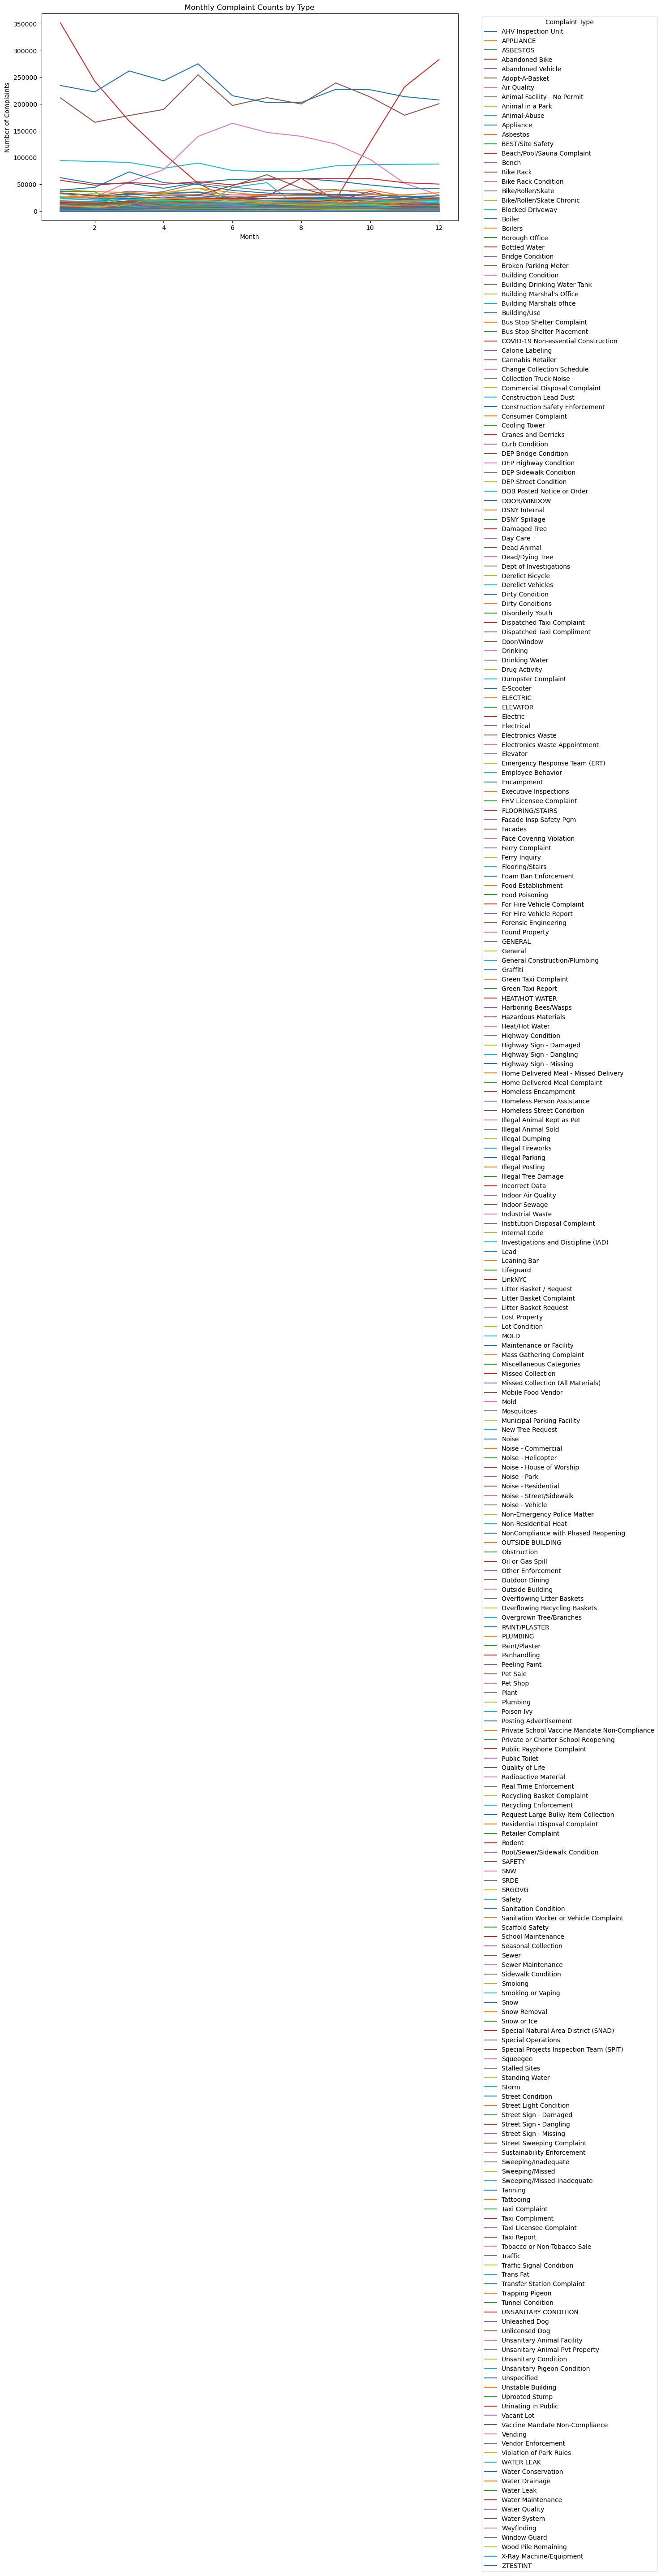

In [53]:
# 4. Are there any complaint types that appear to be seasonal or concentrated in certain time periods?
# Use created_date to group by month. Show your evidence.

df["created_month"] = pd.to_datetime(df["created_date"]).dt.month
complaints_by_month = df.groupby(["created_month", "complaint_type"]).size().unstack(fill_value=0)
complaints_by_month.plot(kind="line", figsize=(12, 6))
plt.title("Monthly Complaint Counts by Type")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.legend(title="Complaint Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


* Plotting all complaint types for a holistic view of what trends are immediately observable.

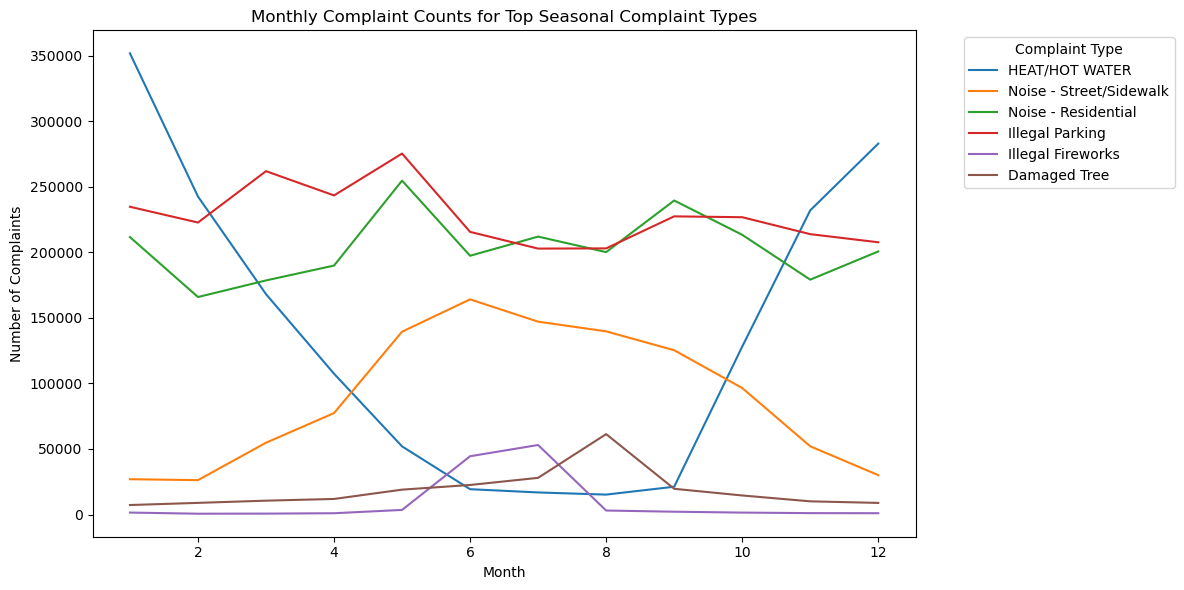

In [ ]:
# Filtering out complaint types with the greatest seasonal variation for a clearer view using .std()
seasonal_complaints = complaints_by_month.std().sort_values(ascending=False).head(6).index
complaints_by_month[seasonal_complaints].plot(kind="line", figsize=(12, 6))
plt.title("Monthly Complaint Counts for Top Seasonal Complaint Types")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.legend(title="Complaint Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

* Top 6 were chosen as these had the highest standard deviations across the months; the other complaint types were more flat year-round.

* Heat/Hot Water, Street and Residential Noise, Illegal Parking, Illegal Fireworks and Damaged Tree complaints all appear to be seasonal. Residential noise and illegal parking seem to peak in month 5

* Heat/Hot Water complaints peak in the colder months (1 and 12) and trickle down as the data approaches months 6, 7, 8, and 9.

In [ ]:
# 5. Identify at least one data quality issue in the dataset
# How did you handle it?

print("Missing Values per Column:")
print(df.isna().sum())

Missing Values per Column:
unique_key                               0
created_date                             0
closed_date                         386430
agency                                   0
agency_name                              0
complaint_type                           0
descriptor                          602988
descriptor_2                      13376565
incident_zip                        229937
intersection_street_1              7464402
intersection_street_2              7456346
address_type                       2761463
city                               1023048
status                                   0
resolution_description              836567
resolution_action_updated_date      165315
community_board                          0
council_district                    427458
police_precinct                          0
borough                                  0
x_coordinate_state_plane            324614
y_coordinate_state_plane            323888
open_data_channel_type     

- There are 386,430 missing closed_date values

In [ ]:
status_counts = df["status"].value_counts()
status_counts

status
Closed         20848981
In Progress      236414
Open              75383
Pending           56672
Assigned          24134
Started            6981
Unspecified        2769
Name: count, dtype: int64

In [ ]:
print(status_counts[1:].sum())

402353


- There are 386,430 missing closed_date values, but 402,353 complaints have non-closed statuses
- This is surprising because the number of missing closed_date values should either be equal or greater than the number of complaints with non-closed statuses
- Due to the fact that a non-closed complaint is expected to not have a closed_date yet

## Hypothesis: 
- Some Closed complaints are also missing closed_date values
- Some non-Closed complaints have closed_date values

In [3]:
# Separating out the closed complaints to check for missing closed_date values
n_closed_missing = df.loc[df["status"] == "Closed", "closed_date"].isna().sum()
print(f"Closed complaints with missing closed_date: {n_closed_missing}")

Closed complaints with missing closed_date: 53923


In [11]:
# Separating out the open complaints to check for missing closed_date values
n_open_missing = df.loc[df["status"] != "Closed", "closed_date"].isna().sum()
print(f"Open complaints with missing closed_date: {n_open_missing}")

Open complaints with missing closed_date: 332507


## Missing closed_date tracking:
* 53,923 Closed complaints missing closed_date
* 332,507 non-Closed complaints missing closed_date
* Total: 386,430

In [30]:
# For the open complaints with a closed_date, we can assume that the closed_date is incorrect
# We will make a new copy of the dataframe and set these closed_date values to NaN
# to reflect that they are not actually closed.
df_new = df.copy()
df_new.loc[(df_new["status"] != "Closed") & (df_new["closed_date"].notna()), "closed_date"] = np.nan

* Handling this data quality issue by nullifying the non-Closed complaints' closed_date values
* Using a copy of the original dataframe, as to not lose the available information, should we need it later

## Re-doing Question 3:

In [31]:
# 3. What is the average resolution time (in days) by agency? 
# Use created_date and closed_date to calculate. 
# Which agency resolves requests fastest — and which is slowest?

df_new["resolution_time"] = (pd.to_datetime(df_new["closed_date"]) - pd.to_datetime(df_new["created_date"])).dt.days
agency_resolution_time = df_new.groupby("agency")["resolution_time"].mean().sort_values(na_position="first")
print("Average Resolution Time by Agency (in days):")
print(agency_resolution_time)

Average Resolution Time by Agency (in days):
agency
NYPD            0.072167
DHS             1.052179
DEP             4.627172
NYC311-PRD      5.221024
DSNY            9.150718
DCWP            9.510033
OSE             9.941655
DFTA           12.004008
DOT            13.290494
HPD            15.848629
OTI            17.591691
DOITT          30.462500
DCA            32.709687
OOS            43.006044
DOB            53.430202
TLC            62.867539
DOE            88.401481
DOHMH         148.336253
DPR           186.336587
EDC           326.180718
Name: resolution_time, dtype: float64


* Slight decrease in response time for NYPD
* Some agencies below NYC311-PRD have switched order; OSE has changed resoution time from 7.4 -> 9.9 days and DOT has gone from 12.7 -> 13.3 days
* TLC has greatest change of resolution time, from 45.7 -> 62.9 days
## Question:
- Are these changes statistically significant?

In [33]:
# Statistical Comparison of Resolution Times Before and After the Closed Date Fix
# By Claude Code

from scipy import stats

# The correct comparison is: removed records vs kept records (truly independent groups).
# The previous version used ttest_ind(rt_orig, rt_new), but rt_new ⊂ rt_orig,
# violating the independence assumption of Welch's t-test.
# This version fixes that by identifying the removed records directly via removed_mask
# and comparing them against the records that were kept.

# Boolean mask identifying records nulled out by the closed_date fix:
# non-Closed complaints that had a closed_date (the "bad" records)
removed_mask = (df["status"] != "Closed") & (df["closed_date"].notna())

results = []
for agency in df["agency"].dropna().unique():
    agency_mask = df["agency"] == agency

    rt_removed = df.loc[agency_mask & removed_mask, "resolution_time"].dropna()   # the "bad" records
    rt_kept    = df.loc[agency_mask & ~removed_mask, "resolution_time"].dropna()  # the "clean" records

    if len(rt_removed) < 2 or len(rt_kept) < 2:
        # Not enough removed records to test — report descriptively only
        results.append({
            "agency":          agency,
            "mean_removed":    round(rt_removed.mean(), 3) if len(rt_removed) else float("nan"),
            "mean_kept":       round(rt_kept.mean(), 3)    if len(rt_kept)    else float("nan"),
            "n_removed":       len(rt_removed),
            "pct_change_mean": float("nan"),
            "cohens_d":        float("nan"),
            "p_value":         float("nan"),
            "significant":     False,
        })
        continue

    mean_removed = rt_removed.mean()
    mean_kept    = rt_kept.mean()

    # How much did the mean shift as a result of removing these records?
    pct_change = (mean_kept - mean_removed) / mean_kept * 100 if mean_kept else float("nan")

    # Cohen's d — pooled std; measures practical effect size
    # Convention: 0.2 = small, 0.5 = medium, 0.8 = large
    pooled_std = np.sqrt((rt_removed.std()**2 + rt_kept.std()**2) / 2)
    cohens_d   = (mean_removed - mean_kept) / pooled_std if pooled_std else float("nan")

    # Welch's t-test — handles unequal sample sizes between removed and kept groups
    _, p = stats.ttest_ind(rt_removed, rt_kept, equal_var=False)

    results.append({
        "agency":          agency,
        "mean_removed":    round(mean_removed, 3),
        "mean_kept":       round(mean_kept, 3),
        "n_removed":       len(rt_removed),
        "pct_change_mean": round(pct_change, 2),
        "cohens_d":        round(cohens_d, 4),
        "p_value":         round(p, 6),
    })

results_df = pd.DataFrame(results)

# Bonferroni correction — divides α by the number of agencies tested
# to control the false positive rate when running many simultaneous tests
alpha_corrected = 0.05 / results_df["p_value"].notna().sum()
results_df["significant"] = results_df["p_value"] < alpha_corrected

# Flag rows where pct_change is unreliable: mean_kept is near zero, so dividing by it
# inflates the percentage into the thousands even for small absolute differences
results_df["pct_note"] = results_df["pct_change_mean"].apply(
    lambda x: "unreliable % (mean_kept ≈ 0)" if pd.notna(x) and abs(x) > 500 else ""
)

results_df = results_df.sort_values("n_removed", ascending=False).reset_index(drop=True)

print(f"Bonferroni-corrected α = {alpha_corrected:.6f}")
print("mean_removed = avg resolution time of the nulled-out records")
print("mean_kept    = avg resolution time of the clean records (= df_new mean)\n")
print(results_df.to_string(index=False))


Bonferroni-corrected α = 0.004167
mean_removed = avg resolution time of the nulled-out records
mean_kept    = avg resolution time of the clean records (= df_new mean)

    agency  mean_removed  mean_kept  n_removed  pct_change_mean   cohens_d  p_value  significant                     pct_note
       DOT        -5.450     13.290      44314           141.01    -0.4261 0.000000         True                             
       DOB        17.694     53.430      20729            66.88    -0.4170 0.000000         True                             
      DSNY       -31.329      9.151       3678           442.36    -0.0449 0.053809        False                             
       DEP      -170.493      4.627        383          3784.62    -1.2930 0.000000         True unreliable % (mean_kept ≈ 0)
      NYPD         1.548      0.072        305         -2044.39     0.2242 0.003719         True unreliable % (mean_kept ≈ 0)
     DOHMH     -1278.458    148.336        179           961.86    -0.2497 0

In [ ]:
# Investigating corrupted closed_date values in DOT, DSNY, DEP, DOHMH, DPR, TLC, DHS, and OSE removed records
# These agencies showed negative mean_removed values in the statistical comparison,
# suggesting a second data quality issue: closed_date values that predate created_date.
# Created by Claude Code

agencies_of_interest = ["DOT", "DSNY", "DEP", "DOHMH", "DPR", "TLC", "DHS", "OSE"]

for agency in agencies_of_interest:
    agency_mask = df["agency"] == agency
    bad = df.loc[agency_mask & removed_mask, ["created_date", "closed_date", "resolution_time", "status"]].copy()
    bad["created_date"] = pd.to_datetime(bad["created_date"])
    bad["closed_date"]  = pd.to_datetime(bad["closed_date"])

    neg = bad[bad["resolution_time"] < 0].sort_values("resolution_time")

    print(f"{'='*65}")
    print(f"  {agency}  —  {len(bad)} removed records  ({len(neg)} with negative resolution_time)")
    print(f"{'='*65}")
    print(f"  closed_date range  : {bad['closed_date'].min().date()}  →  {bad['closed_date'].max().date()}")
    print(f"  created_date range : {bad['created_date'].min().date()}  →  {bad['created_date'].max().date()}")
    print(f"  resolution_time    : {bad['resolution_time'].min():.0f} days  →  {bad['resolution_time'].max():.0f} days")

    if len(neg):
        print(f"\n  Most extreme records (closed_date far before created_date):")
        print(neg[["created_date", "closed_date", "resolution_time", "status"]].head(10).to_string(index=False))

        rt_neg = neg["resolution_time"]
        print(f"\n  Percentile breakdown of negative resolution_time (days):")
        for p in [0, 10, 25, 50, 75, 90, 100]:
            print(f"    p{p:3d}: {rt_neg.quantile(p/100):>12.0f}")
    print()


  DOT  —  44314 removed records  (39249 with negative resolution_time)
  closed_date range  : 2019-10-04  →  2026-06-04
  created_date range : 2020-01-02  →  2026-05-31
  resolution_time    : -378 days  →  629 days

  Most extreme records (closed_date far before created_date):
       created_date         closed_date  resolution_time  status
2023-01-27 14:40:00 2022-01-14 14:40:00           -378.0 Pending
2021-02-17 14:15:00 2020-02-11 14:15:00           -372.0 Pending
2023-01-18 10:06:00 2022-01-12 10:06:00           -371.0 Pending
2023-01-27 14:36:00 2022-01-22 14:35:00           -371.0 Pending
2021-01-11 10:01:00 2020-01-07 10:01:00           -370.0 Pending
2021-05-03 12:22:00 2020-04-30 12:22:00           -368.0 Pending
2023-01-11 11:10:00 2022-01-09 11:10:00           -367.0 Pending
2021-01-19 10:24:00 2020-01-18 10:24:00           -367.0 Pending
2024-02-23 10:16:00 2023-02-22 10:15:00           -367.0 Pending
2021-03-03 09:08:00 2020-03-02 00:25:00           -367.0 Pending

  Perc

In [35]:
# Re-running the comparison after excluding records where closed_date < created_date
# (resolution_time < 0). These represent a second data quality issue — bogus date values
# (1899-12-31, the OLE Automation zero-date) — and would otherwise dominate the mean.

results_clean = []
for agency in df["agency"].dropna().unique():
    agency_mask = df["agency"] == agency

    rt_removed_all = df.loc[agency_mask & removed_mask, "resolution_time"].dropna()
    n_corrupt      = int((rt_removed_all < 0).sum())
    rt_removed     = rt_removed_all[rt_removed_all >= 0]   # drop corrupt-date records
    rt_kept        = df.loc[agency_mask & ~removed_mask, "resolution_time"].dropna()

    if len(rt_removed_all) == 0 or len(rt_kept) < 2:
        continue  # agency had no removed records at all

    if len(rt_removed) < 2:
        # All removed records had the 1899 corrupt date — nothing left to compare
        results_clean.append({
            "agency":          agency,
            "mean_removed":    float("nan"),
            "mean_kept":       round(rt_kept.mean(), 3),
            "n_removed":       0,
            "n_corrupt":       n_corrupt,
            "pct_change_mean": float("nan"),
            "cohens_d":        float("nan"),
            "p_value":         float("nan"),
            "significant":     False,
            "note":            "all removed records had 1899 corrupt date",
        })
        continue

    mean_removed = rt_removed.mean()
    mean_kept    = rt_kept.mean()
    pct_change   = (mean_kept - mean_removed) / mean_kept * 100 if mean_kept else float("nan")
    pooled_std   = np.sqrt((rt_removed.std()**2 + rt_kept.std()**2) / 2)
    cohens_d     = (mean_removed - mean_kept) / pooled_std if pooled_std else float("nan")
    _, p         = stats.ttest_ind(rt_removed, rt_kept, equal_var=False)

    note = "unreliable % (mean_kept ≈ 0)" if pd.notna(pct_change) and abs(pct_change) > 500 else ""

    results_clean.append({
        "agency":          agency,
        "mean_removed":    round(mean_removed, 3),
        "mean_kept":       round(mean_kept, 3),
        "n_removed":       len(rt_removed),
        "n_corrupt":       n_corrupt,
        "pct_change_mean": round(pct_change, 2),
        "cohens_d":        round(cohens_d, 4),
        "p_value":         round(p, 6),
        "significant":     False,
        "note":            note,
    })

clean_df = pd.DataFrame(results_clean)
has_p = clean_df["p_value"].notna()
alpha_clean = 0.05 / has_p.sum()
clean_df.loc[has_p, "significant"] = clean_df.loc[has_p, "p_value"] < alpha_clean
clean_df = clean_df.sort_values("n_removed", ascending=False).reset_index(drop=True)

print("Comparison after excluding records where resolution_time < 0 (1899 corrupt date values)")
print(f"Bonferroni-corrected α = {alpha_clean:.6f}\n")
print(clean_df.to_string(index=False))


Comparison after excluding records where resolution_time < 0 (1899 corrupt date values)
Bonferroni-corrected α = 0.005000

agency  mean_removed  mean_kept  n_removed  n_corrupt  pct_change_mean  cohens_d  p_value  significant                                      note
   DOB        17.694     53.430      20729          0            66.88   -0.4170 0.000000         True                                          
   DOT         0.647     13.290       5065      39249            95.13   -0.2947 0.000000         True                                          
  DSNY         6.522      9.151       3650         28            28.72   -0.0630 0.000000         True                                          
  NYPD         1.548      0.072        305          0         -2044.39    0.2242 0.003719         True              unreliable % (mean_kept ≈ 0)
 DOHMH       218.653    148.336        173          6           -47.40    0.1706 0.049588        False                                          
   DEP 

* Erroneous dates were dropped as it isn't possible for me to manually correct or infer a possible date
# Important Note:
* Complaints with a valid closed_date may possibly not have had their status updated to "Closed"

# Examaning TLC Complaints
- TLC was a flagged as agency of interest, due to the drastic change in resolution_time before and after nullifying non-closed complaints

In [36]:
# Elucidating the Top Complaint Types for TLC
TLC_complaints = df[df["agency"] == "TLC"]["complaint_type"].value_counts().head(10)
print("Top 10 Complaint Types for TLC:")
print(TLC_complaints)

Top 10 Complaint Types for TLC:
complaint_type
For Hire Vehicle Complaint    98097
Taxi Complaint                41789
Lost Property                 37916
Taxi Report                    4220
For Hire Vehicle Report        2325
Green Taxi Complaint           1822
Taxi Compliment                 518
Found Property                  479
Green Taxi Report               194
Dispatched Taxi Complaint        65
Name: count, dtype: int64


In [37]:
vehicle_complaints = df.loc[df["complaint_type"] == "For Hire Vehicle Complaint"][["created_date", "closed_date", "descriptor", "descriptor_2", "status", "borough", "open_data_channel_type", "resolution_time"]]
print("Vehicle Complaints Sample:")
vehicle_complaints.sample(10)

Vehicle Complaints Sample:


,created_date,closed_date,descriptor,descriptor_2,status,borough,open_data_channel_type,resolution_time
3202552,2020-02-09T20:55:30.000,2020-05-08T12:53:54.000,Driver Complaint - Non Passenger,Unsafe Driving,Closed,MANHATTAN,ONLINE,88.0
10000566,2022-04-08T18:42:42.000,NaN,Driver Complaint - Non Passenger,Unsafe Driving,In Progress,QUEENS,ONLINE,NaN
1681079,2023-06-14T12:37:17.000,2023-08-08T15:39:30.000,Driver Complaint - Non Passenger,Unsafe Driving,Closed,MANHATTAN,ONLINE,55.0
1548507,2023-04-05T09:51:24.000,2023-07-03T09:36:51.000,Driver Complaint - Non Passenger,Unsafe Driving,Closed,MANHATTAN,MOBILE,88.0
16830739,2022-11-24T20:36:05.000,2023-04-05T14:53:38.000,Driver Complaint - Non Passenger,Unsafe Driving,Closed,BROOKLYN,ONLINE,131.0
2222304,2024-09-06T19:16:27.000,2025-04-04T15:07:09.000,Driver Complaint - Non Passenger,Unsafe Driving,Closed,MANHATTAN,ONLINE,209.0
2254854,2024-09-21T22:12:04.000,2024-12-31T11:47:56.000,Driver Complaint - Non Passenger,Unsafe Driving,Closed,MANHATTAN,ONLINE,100.0
3417964,2020-07-08T10:02:55.000,2020-08-26T11:01:08.000,Driver Complaint - Non Passenger,Unsafe Driving,Closed,MANHATTAN,ONLINE,49.0
17913595,2024-06-21T09:47:57.000,2024-11-22T10:32:21.000,Driver Complaint - Non Passenger,Unsafe Driving,Closed,BROOKLYN,ONLINE,154.0
4901005,2021-09-03T21:53:13.000,2022-09-16T10:12:48.000,Driver Complaint - Passenger,Cell Phone Use,Closed,BRONX,ONLINE,377.0


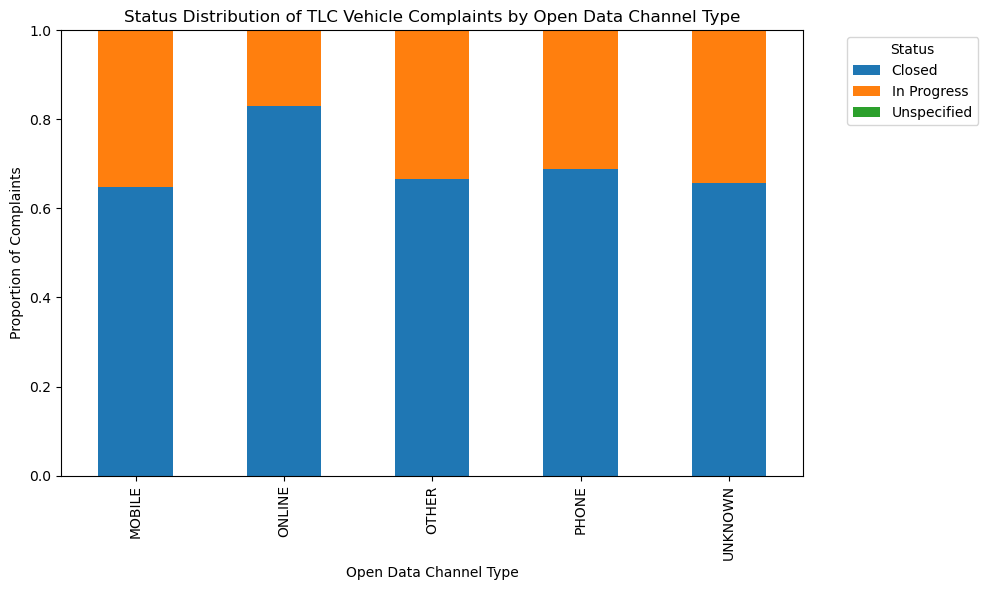

In [38]:
# Analyzing the status of TLC-vehicle complaints based on open_data_channel_type
grouped_tlc_vehicle = vehicle_complaints.groupby("open_data_channel_type")["status"].value_counts(normalize=True).unstack(fill_value=0)
grouped_tlc_vehicle.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Status Distribution of TLC Vehicle Complaints by Open Data Channel Type")
plt.xlabel("Open Data Channel Type")
plt.ylabel("Proportion of Complaints")
plt.legend(title="Status", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [40]:
# Numerical summary of resolution_time for TLC vehicle complaints by open_data_channel_type
summary_tlc_vehicle = vehicle_complaints["open_data_channel_type"].value_counts()
print("Resolution Time Summary for TLC Vehicle Complaints by Open Data Channel Type:")
summary_tlc_vehicle

Resolution Time Summary for TLC Vehicle Complaints by Open Data Channel Type:


open_data_channel_type
ONLINE     72447
MOBILE     13098
PHONE      12089
UNKNOWN      460
OTHER          3
Name: count, dtype: int64

- The ONLINE channel type has a much higher closure rate (~80%) than every other channel (~60-65%)
- It also contains the greatest volume of complaints (72,447)

# Focusing on some agencies with True significant p-values (e.g. DOT, DOB, etc.) 
- before and after nullifying closed_date values

In [21]:
# Elucidating the Top Complaint Types for DOT
DOT_complaints = df[df["agency"] == "DOT"]["complaint_type"].value_counts().head(10)
print("Top 10 Complaint Types for DOT:")
print(DOT_complaints)

Top 10 Complaint Types for DOT:
complaint_type
Street Condition            472858
Street Light Condition      272754
Traffic Signal Condition    255021
Sidewalk Condition          156479
Curb Condition               42320
Street Sign - Damaged        32190
Outdoor Dining               31302
Broken Parking Meter         29477
Street Sign - Missing        25428
Street Sign - Dangling       23288
Name: count, dtype: int64


In [ ]:
street_complaints = df.loc[df["complaint_type"] == "Street Condition"][["created_date", "closed_date", "descriptor", "descriptor_2", "status", "borough", "open_data_channel_type", "resolution_time"]]
print("Street Complaints Sample:")
street_complaints.sample(10)

Street Complaints Sample:


,created_date,closed_date,descriptor,descriptor_2,status,borough,open_data_channel_type,resolution_time
10157877,2022-07-12T08:55:07.000,2022-07-14T11:13:57.000,Failed Street Repair,NaN,Closed,QUEENS,ONLINE,2.0
2111397,2024-07-09T16:16:02.000,2024-07-11T08:36:51.000,Plate Condition - Noisy,NaN,Closed,MANHATTAN,PHONE,1.0
167324,2021-01-07T13:42:50.000,2021-01-11T16:38:36.000,Blocked - Construction,NaN,Closed,MANHATTAN,ONLINE,4.0
3109989,2025-12-02T14:59:01.000,2025-12-03T09:55:00.000,Pothole,NaN,Closed,MANHATTAN,UNKNOWN,0.0
15238173,2021-02-24T15:04:11.000,2021-02-25T11:00:00.000,Pothole,NaN,Closed,BROOKLYN,UNKNOWN,0.0
10193406,2022-07-29T10:38:41.000,2022-07-29T22:00:00.000,Pothole,NaN,Closed,QUEENS,UNKNOWN,0.0
9908560,2021-07-25T14:20:40.000,2021-07-26T05:15:00.000,Pothole,NaN,Closed,QUEENS,UNKNOWN,0.0
10178489,2022-07-20T23:15:10.000,2022-07-21T20:00:00.000,Pothole,NaN,Closed,QUEENS,UNKNOWN,0.0
331796,2021-03-11T17:53:28.000,2021-03-11T22:25:00.000,Pothole,NaN,Closed,MANHATTAN,UNKNOWN,0.0
10979264,2024-02-06T14:35:24.000,2024-02-06T17:54:00.000,Pothole,NaN,Closed,QUEENS,UNKNOWN,0.0


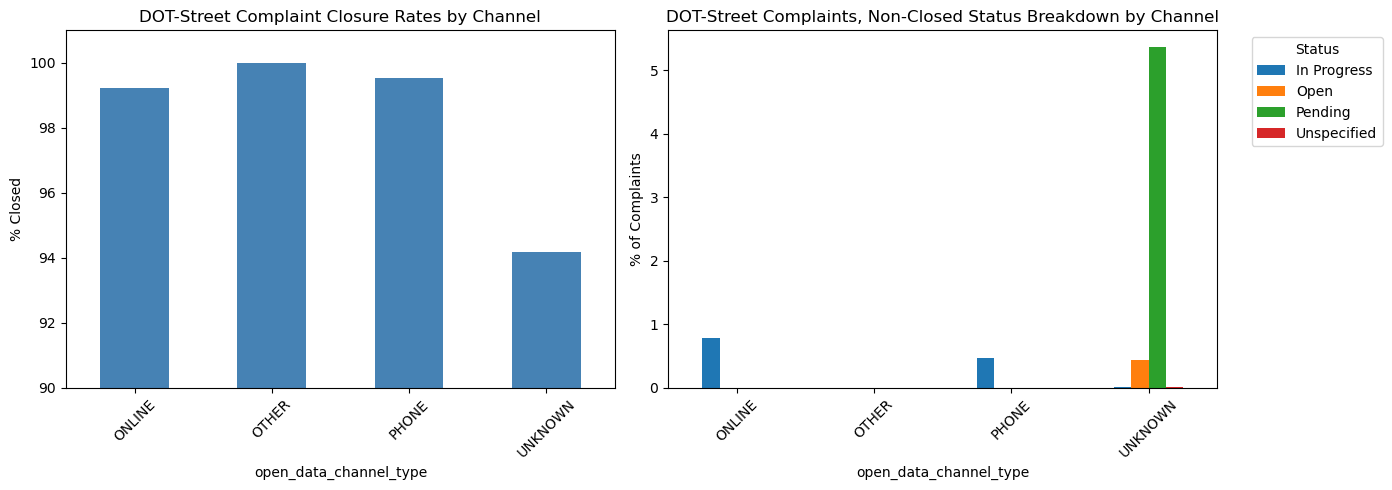

In [17]:
# Analyzing the status of DOT-Street Complaints based on open_data_channel_type
# Layout by Claude Code

grouped_dot_street = street_complaints.groupby("open_data_channel_type")["status"].value_counts(normalize=True).unstack(fill_value=0)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: closure rate per channel
closure_rate = grouped_dot_street["Closed"] * 100
closure_rate.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("DOT-Street Complaint Closure Rates by Channel")
axes[0].set_ylabel("% Closed")
axes[0].set_ylim(90, 101)   # zoom in so differences are visible
axes[0].tick_params(axis="x", rotation=45)

# Right: breakdown of non-Closed statuses only
non_closed = grouped_dot_street.drop(columns="Closed", errors="ignore") * 100
non_closed = non_closed.loc[:, (non_closed > 0).any()]   # drop all-zero columns
non_closed.plot(kind="bar", ax=axes[1])
axes[1].set_title("DOT-Street Complaints, Non-Closed Status Breakdown by Channel")
axes[1].set_ylabel("% of Complaints")
axes[1].legend(title="Status", bbox_to_anchor=(1.05, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [42]:
# Count of DOT-Street Complaints by Open Data Channel Type
summary_street_complaints = street_complaints["open_data_channel_type"].value_counts()
print("Count of DOT-Street Complaints by Open Data Channel Type:")
summary_street_complaints

Count of DOT-Street Complaints by Open Data Channel Type:


open_data_channel_type
UNKNOWN    298080
PHONE       89569
ONLINE      85505
OTHER          21
Name: count, dtype: int64

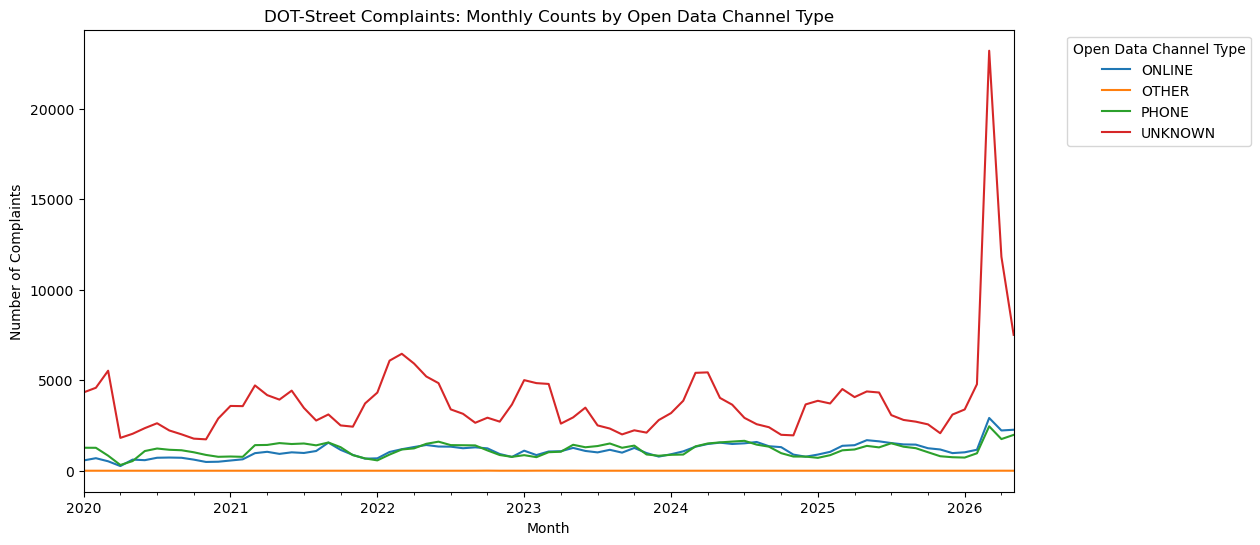

In [44]:
# Analyzing open_data_channel_type distribution for DOT-Street Complaints over time
street_complaints["created_month"] = pd.to_datetime(street_complaints["created_date"]).dt.to_period("M").dt.to_timestamp()
channel_monthly = street_complaints.groupby(["created_month", "open_data_channel_type"]).size().unstack(fill_value=0)
channel_monthly.plot(kind="line", figsize=(12, 6))
plt.title("DOT-Street Complaints: Monthly Counts by Open Data Channel Type")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.legend(title="Open Data Channel Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

- There are no MOBILE data points for DOT-Street Complaints
- UNKNOWN has had a massive peak early 2026

## Question the data alone can't answer:
- Could the UNKNOWN data possibly be missed MOBILE data?

In [18]:
# Elucidating the Top Complaint Types for DOB
DOB_complaints = df[df["agency"] == "DOB"]["complaint_type"].value_counts().head(10)
print("Top 10 Complaint Types for DOB:")
print(DOB_complaints)

Top 10 Complaint Types for DOB:
complaint_type
General Construction/Plumbing              233957
Building/Use                               122160
Elevator                                   114101
Real Time Enforcement                       31007
Special Projects Inspection Team (SPIT)     24897
Emergency Response Team (ERT)               21525
Boilers                                     21046
Plumbing                                    19099
Electrical                                  13448
COVID-19 Non-essential Construction          7322
Name: count, dtype: int64


In [ ]:
construction_complaints = df.loc[df["complaint_type"] == "General Construction/Plumbing"][["created_date", "closed_date", "descriptor", "descriptor_2", "status", "borough", "open_data_channel_type", "resolution_time"]]
print("Construction/Plumbing Complaints Sample:")
construction_complaints.sample(10)

Construction/Plumbing Complaints Sample:


,created_date,closed_date,descriptor,descriptor_2,status,borough,open_data_channel_type,resolution_time
15851403,2021-10-22T08:44:58.000,2021-10-24T00:00:00.000,Building Shaking/Vibrating/Structural Stability,NaN,Closed,BROOKLYN,UNKNOWN,1.0
15019150,2020-11-19T20:26:59.000,2020-12-31T00:00:00.000,Cons - Contrary/Beyond Approved Plans/Permits,NaN,Closed,BROOKLYN,UNKNOWN,41.0
19865301,2020-06-28T11:55:41.000,2020-06-29T00:00:00.000,Sidewalk Shed/Pipe Scafford - Inadequate Defec...,NaN,Closed,BROOKLYN,UNKNOWN,0.0
15954357,2021-11-26T12:59:51.000,2021-11-28T00:00:00.000,Site Conditions Endangering Workers,NaN,Closed,BROOKLYN,UNKNOWN,1.0
14629335,2020-02-18T16:52:13.000,2020-02-19T00:00:00.000,Site Conditions Endangering Workers,NaN,Closed,STATEN ISLAND,UNKNOWN,0.0
17373801,2023-06-27T12:40:00.000,2023-06-29T00:00:00.000,Sidewalk Shed/Pipe Scafford - Inadequate Defec...,NaN,Closed,BROOKLYN,UNKNOWN,1.0
9608272,2021-09-27T13:17:27.000,2022-02-15T00:00:00.000,Curb Cut/Driveway/Carport - Illegal,NaN,Closed,QUEENS,UNKNOWN,140.0
19361569,2025-11-07T13:32:01.000,2025-11-10T00:00:00.000,Working Contrary To Stop Work Order,NaN,Closed,BROOKLYN,UNKNOWN,2.0
278785,2021-03-24T14:28:56.000,2021-10-18T00:00:00.000,Debris - Falling Or In Danger Of Falling,NaN,Closed,MANHATTAN,UNKNOWN,207.0
13338390,2023-09-13T08:28:10.000,2023-09-13T08:28:10.000,Building Shaking/Vibrating/Structural Stability,NaN,Closed,QUEENS,UNKNOWN,0.0


In [23]:
# Analyzing the status of DOB-Construction/Plumbing complaints based on open_data_channel_type
grouped_dob_construction = construction_complaints.groupby("open_data_channel_type")["status"].value_counts(normalize=True).unstack(fill_value=0)
grouped_dob_construction

status,Assigned,Closed,Open
open_data_channel_type,,,
UNKNOWN,0.013229,0.971426,0.015345


# SQL Query

In [45]:
# DuckDB and SQLite Integration
# Set-up using Claude Code

import duckdb
import sqlite3

# Querying parquet files directly instead of df; avoids loading the 14GB DataFrame
# into DuckDB on top of what's already in memory.
# resolution_time is computed in SQL since it's not stored in the parquet files.
db = duckdb.sql("""
    SELECT
        agency,
        borough,
        COUNT(*)                                                         AS n_complaints,
        AVG(
            DATEDIFF('day',
                TRY_CAST(created_date AS TIMESTAMP),
                TRY_CAST(closed_date  AS TIMESTAMP))
        )                                                                AS avg_resolution_days,
        SUM(CASE WHEN status = 'Closed' THEN 1 ELSE 0 END)              AS n_closed,
        ROUND(
            100.0 * SUM(CASE WHEN status = 'Closed' THEN 1 ELSE 0 END)
                  / COUNT(*), 2
        )                                                                AS pct_closed
    FROM read_parquet('nyc311_by_borough/311_*.parquet')
    WHERE agency  IS NOT NULL
      AND borough NOT IN ('UNKNOWN', 'UNSPECIFIED')
    GROUP BY agency, borough
    ORDER BY agency, borough
""").df()

print(f"Query returned {len(db)} rows")
print(db.head(15).to_string(index=False))


Query returned 120 rows
agency       borough  n_complaints  avg_resolution_days  n_closed  pct_closed
 3-1-1        QUEENS             1                  NaN       0.0        0.00
   DCA         BRONX          5663            29.780682    5663.0      100.00
   DCA      BROOKLYN          8120            30.001232    8120.0      100.00
   DCA     MANHATTAN          6117            35.140919    6117.0      100.00
   DCA        QUEENS          7023            38.903602    7023.0      100.00
   DCA STATEN ISLAND           909            32.441144     909.0      100.00
   DCA   Unspecified            73           171.712329      73.0      100.00
  DCWP         BRONX         18639            10.797185   17897.0       96.02
  DCWP      BROOKLYN         32571            10.638574   31333.0       96.20
  DCWP     MANHATTAN         34603             8.983227   33145.0       95.79
  DCWP        QUEENS         27834            10.839828   26711.0       95.97
  DCWP STATEN ISLAND          3477      

In [49]:
# --- 2. Saving result to a local SQLite database ---
conn = sqlite3.connect("nyc311_complaints.db")
db.to_sql("agency_borough_summary", conn, if_exists="replace", index=False)
conn.close()
print("\nSaved to nyc311_complaints.db → table: agency_borough_summary")

# --- 3. Verifying by reading back from SQLite ---
conn = sqlite3.connect("nyc311_complaints.db")
check = pd.read_sql("SELECT * FROM agency_borough_summary LIMIT 5", conn)
conn.close()
print("\nRead back from SQLite:")
print(check.to_string(index=False))


Saved to nyc311_complaints.db → table: agency_borough_summary

Read back from SQLite:
agency   borough  n_complaints  avg_resolution_days  n_closed  pct_closed
 3-1-1    QUEENS             1                  NaN       0.0         0.0
   DCA     BRONX          5663            29.780682    5663.0       100.0
   DCA  BROOKLYN          8120            30.001232    8120.0       100.0
   DCA MANHATTAN          6117            35.140919    6117.0       100.0
   DCA    QUEENS          7023            38.903602    7023.0       100.0


# Query to Parse out Resolution Time by Status

In [50]:
avg_resolution_by_status = duckdb.sql("""
    SELECT
        status,
        COUNT(*)                                             AS n_complaints,
        AVG(
            DATEDIFF('day',
                TRY_CAST(created_date AS TIMESTAMP),
                TRY_CAST(closed_date  AS TIMESTAMP))
        )                                                    AS avg_resolution_days
    FROM read_parquet('nyc311_by_borough/311_*.parquet')
    WHERE borough NOT IN ('UNKNOWN', 'UNSPECIFIED')
    GROUP BY status
    ORDER BY avg_resolution_days DESC NULLS FIRST
""").df()

print(avg_resolution_by_status.to_string(index=False))


     status  n_complaints  avg_resolution_days
     Cancel             1                  NaN
   Assigned         24182            23.032260
     Closed      20885958            19.680452
Unspecified          2771            12.219903
    Started          6983             7.204225
    Pending         56791            -7.078551
       Open         75427            -7.901373
In Progress        238517        -29419.132450


In [52]:
conn = sqlite3.connect("nyc311_complaints.db")
df_summary = pd.read_sql("SELECT * FROM agency_borough_summary WHERE agency = 'TLC'", conn)
conn.close()
print(df_summary.to_string(index=False))

agency       borough  n_complaints  avg_resolution_days  n_closed  pct_closed
   TLC         BRONX          6567            49.883177    4567.0       69.54
   TLC      BROOKLYN         27244            47.326935   20564.0       75.48
   TLC     MANHATTAN        116569            43.549367   95469.0       81.90
   TLC        QUEENS         36423            54.573205   26288.0       72.17
   TLC STATEN ISLAND           731            75.551876     453.0       61.97
   TLC   Unspecified          3537            63.441538    2523.0       71.33


===========================================================================================================

# Final Question:
What's one thing this dataset can't tell you that you'd want to know? What additional data would change your analysis?

- I'd want to know two things:
    1. Are complaints with closed_date values all automatically considered closed, and if so how are they updated?
    2. Does each agency have a different way of labeling their open_data_channel_types?

- It would help to correct/clean this data before entering a predictive model pipeline, which would be my next step in this analysis
- Would want to see if changes in administration have an affect on 311 service requests, especially when seeing the spike in the "DOT-Street Complaints: Monthly Counts by Open Data Channel Type" line graph after Mamdani's 2026 election

# Insight Brief

I analyzed NYC 311 service requests from 2020 to 2026 across all five boroughs to understand what complaints New Yorkers filed most often, and how quickly they were resolved.

The analysis revealed a couple of data quality issues that should be addressed before drawing further conclusions: 1) Several complaints marked as "Closed" were missing a closure date, while others that weren't marked as closed had one recorded. 2) In some cases, closure dates appear before the complaint was even submitted, making them unreliable, and 3), complaints marked "In Progress" were the most frequently affected by these inconsistencies.

I'd recommend that each agency first determine whether closure dates are entered manually or pulled automatically from another system. This will help pinpoint where the inconsistencies are being introduced. From there, validation rules should be put in place to prevent a complaint from being marked "Closed" without a corresponding closure date and to flag any records in which the closure date precedes the submission date.
